# NFL Sack Probability Model
## Swish Analytics Modeling Challenge

**Objective:** Build a model to predict the probability that a given pass play results in a sack.

**Data:** NFL play-by-play data from the 2021–2023 seasons, supplemented with advanced stats, depth charts, snap counts, and roster data.

**Approach:**
1. Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Model Building
4. Evaluation & Calibration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

## 1. Data Loading

In [2]:
# Load play-by-play data for all three seasons
pbp_2021 = pd.read_csv('../data/play_by_play_2021.csv', low_memory=False)
pbp_2022 = pd.read_csv('../data/play_by_play_2022.csv', low_memory=False)
pbp_2023 = pd.read_csv('../data/play_by_play_2023.csv', low_memory=False)

# Combine into one dataframe
pbp = pd.concat([pbp_2021, pbp_2022, pbp_2023], ignore_index=True)

print(f"Total plays: {len(pbp):,}")
print(f"Columns: {pbp.shape[1]}")
print(f"Seasons: {pbp['season'].unique()}")

Total plays: 149,021
Columns: 372
Seasons: [2021 2022 2023]


## 2. Exploratory Data Analysis
### 2.1 Target Variable — Sack Rate

In [3]:
# Filter to pass plays only (dropbacks)
pass_plays = pbp[pbp['qb_dropback'] == 1].copy()

print(f"Total pass plays (dropbacks): {len(pass_plays):,}")
print(f"Total sacks: {int(pass_plays['sack'].sum()):,}")
print(f"Sack rate: {pass_plays['sack'].mean():.4f} ({pass_plays['sack'].mean()*100:.2f}%)")
print(f"\nClass distribution:")
print(pass_plays['sack'].value_counts())

Total pass plays (dropbacks): 65,131
Total sacks: 4,130
Sack rate: 0.0634 (6.34%)

Class distribution:
sack
0.0    61001
1.0     4130
Name: count, dtype: int64


### 2.2 Class Distribution & Sack Rate by Season

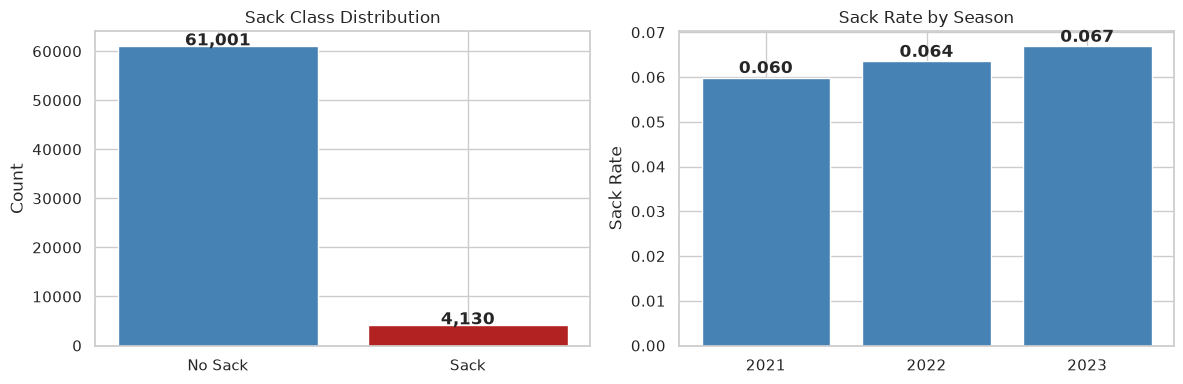

In [5]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['No Sack', 'Sack'], 
            [pass_plays['sack'].value_counts()[0], pass_plays['sack'].value_counts()[1]],
            color=['steelblue', 'firebrick'])
axes[0].set_title('Sack Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([61001, 4130]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Sack rate by season
sack_by_season = pass_plays.groupby('season')['sack'].mean()
axes[1].bar(sack_by_season.index.astype(str), sack_by_season.values, color='steelblue')
axes[1].set_title('Sack Rate by Season')
axes[1].set_ylabel('Sack Rate')
for i, v in enumerate(sack_by_season.values):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../nfl/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Finding:** Sack rate has increased steadily from 6.0% in 2021 to 6.7% in 2023, suggesting a gradual shift in either offensive line performance, defensive pass rush effectiveness, or play-calling tendencies league-wide. Class imbalance (~15:1) will be addressed during modeling via `scale_pos_weight` in XGBoost.

### 2.3 Sack Rate by Situational Factors

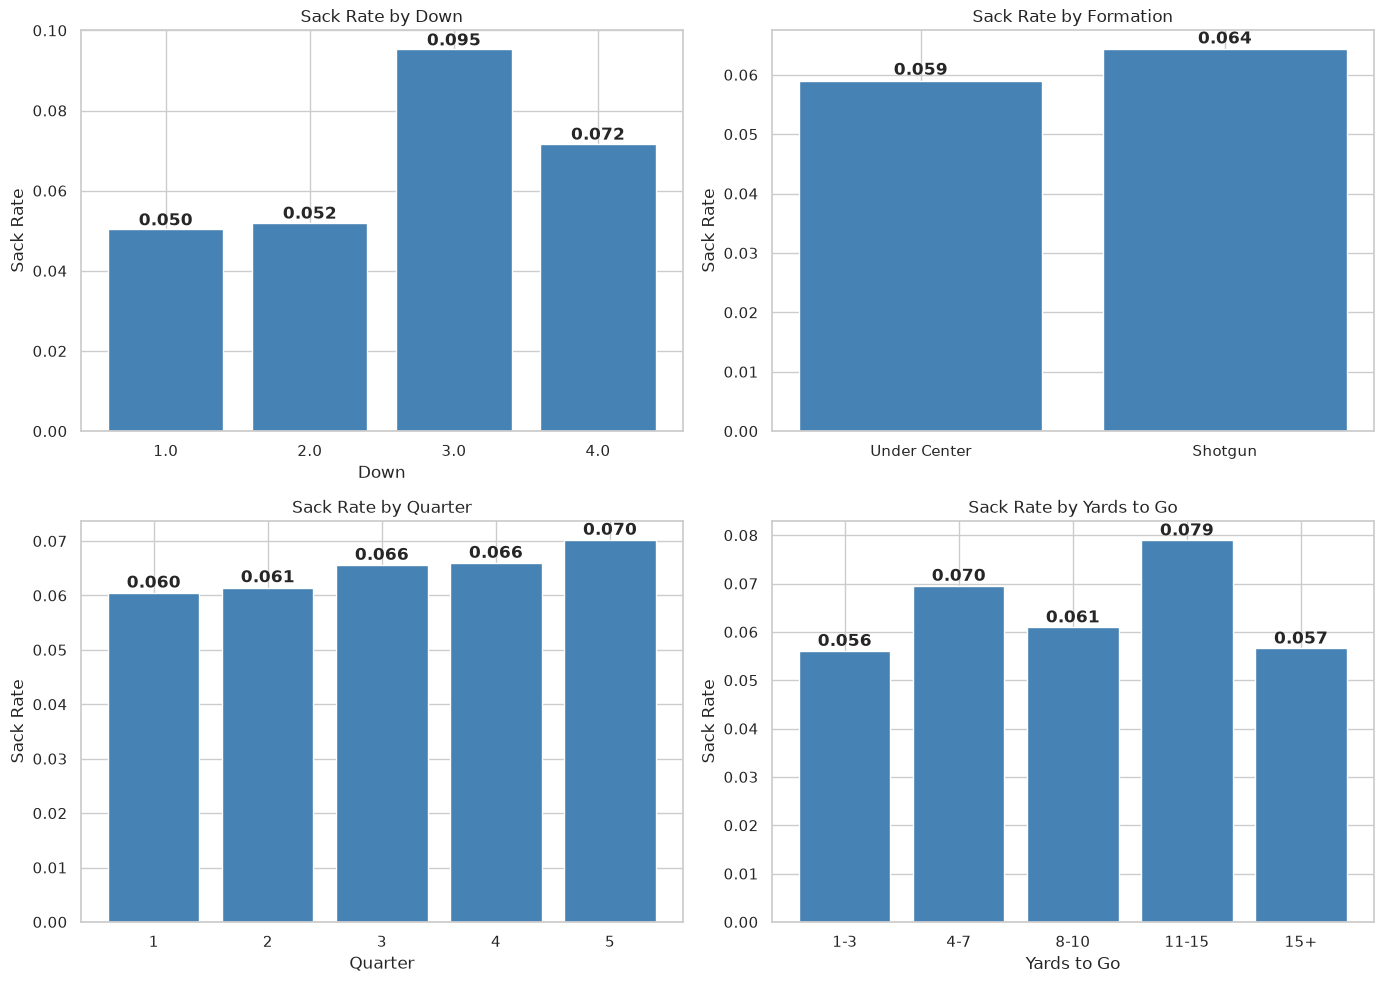

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By down
sack_by_down = pass_plays.groupby('down')['sack'].mean()
axes[0,0].bar(sack_by_down.index.astype(str), sack_by_down.values, color='steelblue')
axes[0,0].set_title('Sack Rate by Down')
axes[0,0].set_xlabel('Down')
axes[0,0].set_ylabel('Sack Rate')
for i, v in enumerate(sack_by_down.values):
    axes[0,0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# By shotgun
sack_by_shotgun = pass_plays.groupby('shotgun')['sack'].mean()
axes[0,1].bar(['Under Center', 'Shotgun'], sack_by_shotgun.values, color='steelblue')
axes[0,1].set_title('Sack Rate by Formation')
axes[0,1].set_ylabel('Sack Rate')
for i, v in enumerate(sack_by_shotgun.values):
    axes[0,1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# By quarter
sack_by_qtr = pass_plays.groupby('qtr')['sack'].mean()
axes[1,0].bar(sack_by_qtr.index.astype(str), sack_by_qtr.values, color='steelblue')
axes[1,0].set_title('Sack Rate by Quarter')
axes[1,0].set_xlabel('Quarter')
axes[1,0].set_ylabel('Sack Rate')
for i, v in enumerate(sack_by_qtr.values):
    axes[1,0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# By yards to go buckets
pass_plays['ydstogo_bucket'] = pd.cut(pass_plays['ydstogo'], 
                                       bins=[0, 3, 7, 10, 15, 100], 
                                       labels=['1-3', '4-7', '8-10', '11-15', '15+'])
sack_by_ydstogo = pass_plays.groupby('ydstogo_bucket', observed=True)['sack'].mean()
axes[1,1].bar(sack_by_ydstogo.index.astype(str), sack_by_ydstogo.values, color='steelblue')
axes[1,1].set_title('Sack Rate by Yards to Go')
axes[1,1].set_xlabel('Yards to Go')
axes[1,1].set_ylabel('Sack Rate')
for i, v in enumerate(sack_by_ydstogo.values):
    axes[1,1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../nfl/figures/sack_rate_situational.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Findings:**
- **Down:** 3rd down has by far the highest sack rate (9.5%), as defenses pin their ears back in obvious passing situations
- **Formation:** Shotgun slightly higher than under center (6.4% vs 5.9%) — counterintuitive but likely reflects the types of plays called from each formation
- **Quarter:** Sack rate increases as the game progresses, peaking in OT (Q5 at 7.0%), possibly due to fatigue or desperation passing
- **Yards to Go:** 11-15 yards to go has the highest sack rate (7.9%), likely because defenses know a pass is coming and QBs hold the ball longer looking for chunk plays

### 2.4 Sack Rate by Field Position & Score Differential

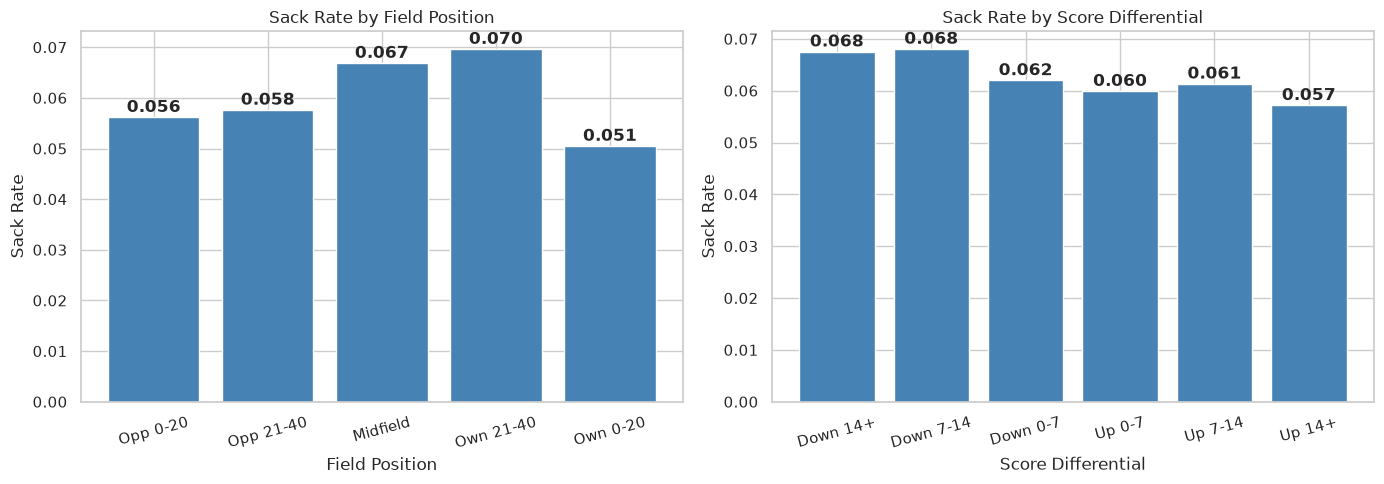

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By field position (yardline buckets)
pass_plays['yardline_bucket'] = pd.cut(pass_plays['yardline_100'],
                                        bins=[0, 20, 40, 60, 80, 100],
                                        labels=['Opp 0-20', 'Opp 21-40', 'Midfield', 'Own 21-40', 'Own 0-20'])
sack_by_yardline = pass_plays.groupby('yardline_bucket', observed=True)['sack'].mean()
axes[0].bar(sack_by_yardline.index.astype(str), sack_by_yardline.values, color='steelblue')
axes[0].set_title('Sack Rate by Field Position')
axes[0].set_xlabel('Field Position')
axes[0].set_ylabel('Sack Rate')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(sack_by_yardline.values):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# By score differential buckets
pass_plays['score_diff_bucket'] = pd.cut(pass_plays['score_differential'],
                                          bins=[-50, -14, -7, 0, 7, 14, 50],
                                          labels=['Down 14+', 'Down 7-14', 'Down 0-7', 'Up 0-7', 'Up 7-14', 'Up 14+'])
sack_by_score = pass_plays.groupby('score_diff_bucket', observed=True)['sack'].mean()
axes[1].bar(sack_by_score.index.astype(str), sack_by_score.values, color='steelblue')
axes[1].set_title('Sack Rate by Score Differential')
axes[1].set_xlabel('Score Differential')
axes[1].set_ylabel('Sack Rate')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(sack_by_score.values):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../nfl/figures/sack_rate_field_score.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Findings:**
- **Field Position:** Sack rate peaks in a team's own territory (7.0% at Own 21-40), likely because QBs are more cautious about taking chances deep in their own end, holding the ball longer. Drops sharply in the red zone (5.1%) where the field compresses and routes are shorter.
- **Score Differential:** Teams losing by 7+ points have the highest sack rates (6.8%), consistent with desperation passing where defenses can pin their ears back knowing a pass is coming. Teams with a lead are slightly more protected, likely due to more conservative, quicker-developing play calls.

## 3. Feature Engineering
### 3.1 Base Situational Features

In [8]:
# Start with a clean copy of pass plays
df = pass_plays.copy()

# Base situational features
df['is_third_down'] = (df['down'] == 3).astype(int)
df['is_fourth_down'] = (df['down'] == 4).astype(int)
df['ydstogo_log'] = np.log1p(df['ydstogo'])
df['in_red_zone'] = (df['yardline_100'] <= 20).astype(int)
df['in_own_territory'] = (df['yardline_100'] >= 60).astype(int)
df['losing_by_two_scores'] = (df['score_differential'] <= -14).astype(int)
df['game_seconds_remaining'] = df['game_seconds_remaining'].fillna(0)
df['two_minute_drill'] = (
    ((df['qtr'] == 2) | (df['qtr'] == 4)) & 
    (df['half_seconds_remaining'] <= 120)
).astype(int)

print("Base features created")
print(df[['is_third_down', 'is_fourth_down', 'ydstogo_log', 'in_red_zone', 
          'in_own_territory', 'losing_by_two_scores', 'two_minute_drill']].head())

Base features created
   is_third_down  is_fourth_down  ydstogo_log  in_red_zone  in_own_territory  \
3              0               0     2.639057            0                 1   
4              1               0     2.397895            0                 1   
6              0               0     2.397895            0                 1   
8              0               0     2.944439            0                 0   
9              0               0     2.890372            0                 0   

   losing_by_two_scores  two_minute_drill  
3                     0                 0  
4                     0                 0  
6                     0                 0  
8                     0                 0  
9                     0                 0  


### 3.2 Rolling Team Sack Rate Features

In [9]:
# Sort by game and play order
df = df.sort_values(['season', 'week', 'game_id', 'play_id']).reset_index(drop=True)

# Rolling offensive sack rate allowed (posteam) — last 4 weeks
df['posteam_sack_rate_rolling'] = (
    df.groupby(['season', 'posteam'])['sack']
    .transform(lambda x: x.shift(1).rolling(window=4*50, min_periods=10).mean())
)

# Rolling defensive sack rate (defteam) — last 4 weeks
df['defteam_sack_rate_rolling'] = (
    df.groupby(['season', 'defteam'])['sack']
    .transform(lambda x: x.shift(1).rolling(window=4*50, min_periods=10).mean())
)

# Fill nulls with league average
league_avg = df['sack'].mean()
df['posteam_sack_rate_rolling'] = df['posteam_sack_rate_rolling'].fillna(league_avg)
df['defteam_sack_rate_rolling'] = df['defteam_sack_rate_rolling'].fillna(league_avg)

print("Rolling features created")
print(df[['posteam', 'defteam', 'posteam_sack_rate_rolling', 'defteam_sack_rate_rolling']].describe())

Rolling features created
       posteam_sack_rate_rolling  defteam_sack_rate_rolling
count               65131.000000               65131.000000
mean                    0.062829                   0.063629
std                     0.027239                   0.024468
min                     0.000000                   0.000000
25%                     0.045000                   0.050000
50%                     0.060000                   0.061947
75%                     0.078125                   0.075000
max                     0.363636                   0.363636


### 3.3 Rolling QB Sack Rate & Weather Features

In [10]:
# Rolling QB sack rate (how often this QB gets sacked)
df['qb_sack_rate_rolling'] = (
    df.groupby(['season', 'passer_player_name'])['sack']
    .transform(lambda x: x.shift(1).rolling(window=100, min_periods=10).mean())
)
df['qb_sack_rate_rolling'] = df['qb_sack_rate_rolling'].fillna(league_avg)

# Weather features
df['wind'] = pd.to_numeric(df['wind'], errors='coerce').fillna(0)
df['temp'] = pd.to_numeric(df['temp'], errors='coerce').fillna(70)
df['is_dome'] = df['roof'].isin(['dome', 'closed']).astype(int)
df['high_wind'] = (df['wind'] >= 15).astype(int)

# No huddle / hurry up
df['no_huddle'] = df['no_huddle'].fillna(0).astype(int)

print("QB and weather features created")
print(df[['qb_sack_rate_rolling', 'wind', 'temp', 'is_dome', 'high_wind', 'no_huddle']].describe())

QB and weather features created
       qb_sack_rate_rolling          wind          temp       is_dome  \
count          65131.000000  65131.000000  65131.000000  65131.000000   
mean               0.064767      4.627090     61.781226      0.300395   
std                0.033765      5.879407     14.849482      0.458433   
min                0.000000      0.000000     -4.000000      0.000000   
25%                0.040000      0.000000     53.000000      0.000000   
50%                0.062500      1.000000     70.000000      0.000000   
75%                0.080000      8.000000     70.000000      1.000000   
max                0.400000     44.000000     90.000000      1.000000   

          high_wind     no_huddle  
count  65131.000000  65131.000000  
mean       0.065545      0.116596  
std        0.247487      0.320940  
min        0.000000      0.000000  
25%        0.000000      0.000000  
50%        0.000000      0.000000  
75%        0.000000      0.000000  
max        1.000000   

### 3.4 Final Feature Set Assembly

In [11]:
# Final feature list
features = [
    # Situational
    'down', 'ydstogo', 'ydstogo_log', 'yardline_100',
    'is_third_down', 'is_fourth_down', 'in_red_zone', 'in_own_territory',
    'losing_by_two_scores', 'two_minute_drill',
    'score_differential', 'wp', 'qtr', 'half_seconds_remaining',
    
    # Formation / play type
    'shotgun', 'no_huddle',
    
    # Rolling team rates
    'posteam_sack_rate_rolling', 'defteam_sack_rate_rolling',
    
    # Rolling QB rate
    'qb_sack_rate_rolling',
    
    # Weather
    'wind', 'temp', 'is_dome', 'high_wind',
]

target = 'sack'

# Drop rows with nulls in features or target
model_df = df[features + [target]].dropna()

print(f"Modeling dataset shape: {model_df.shape}")
print(f"Sack rate in modeling dataset: {model_df[target].mean():.4f}")
print(f"\nNull counts:\n{model_df.isnull().sum().sum()} total nulls")

Modeling dataset shape: (64846, 24)
Sack rate in modeling dataset: 0.0637

Null counts:
0 total nulls


## 4. Model Building
### 4.1 Train/Test Split

In [12]:
X = model_df[features]
y = model_df[target]

# Time-based split — train on 2021-2022, test on 2023
train_mask = df.loc[model_df.index, 'season'] < 2023
X_train = X[train_mask]
X_test = X[~train_mask]
y_train = y[train_mask]
y_test = y[~train_mask]

print(f"Train size: {len(X_train):,} plays ({y_train.mean():.4f} sack rate)")
print(f"Test size:  {len(X_test):,} plays ({y_test.mean():.4f} sack rate)")
print(f"\nUsing time-based split: train on 2021-2022, test on 2023")
print("(Prevents data leakage from future games informing past predictions)")

Train size: 43,106 plays (0.0620 sack rate)
Test size:  21,740 plays (0.0671 sack rate)

Using time-based split: train on 2021-2022, test on 2023
(Prevents data leakage from future games informing past predictions)


### 4.2 XGBoost Model

In [13]:
# Calculate scale_pos_weight to handle class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f} (neg/pos ratio)")

# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nModel training complete")

scale_pos_weight: 15.14 (neg/pos ratio)
[0]	validation_0-logloss:0.69124
[50]	validation_0-logloss:0.66096
[100]	validation_0-logloss:0.64550
[150]	validation_0-logloss:0.63077
[200]	validation_0-logloss:0.61821
[250]	validation_0-logloss:0.60514
[300]	validation_0-logloss:0.59348
[350]	validation_0-logloss:0.58382
[400]	validation_0-logloss:0.57310
[450]	validation_0-logloss:0.56479
[499]	validation_0-logloss:0.55585

Model training complete


### 4.3 Model Evaluation

In [14]:
# Generate predictions
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Core metrics
auc = roc_auc_score(y_test, y_pred_proba)
logloss = log_loss(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print("=" * 40)
print("XGBoost Model Evaluation — 2023 Test Set")
print("=" * 40)
print(f"ROC-AUC:     {auc:.4f}")
print(f"Log Loss:    {logloss:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"Baseline Log Loss (predict mean): {log_loss(y_test, [y_train.mean()] * len(y_test)):.4f}")
print(f"Baseline Brier Score:             {brier_score_loss(y_test, [y_train.mean()] * len(y_test)):.4f}")

XGBoost Model Evaluation — 2023 Test Set
ROC-AUC:     0.5683
Log Loss:    0.5559
Brier Score: 0.1872
Baseline Log Loss (predict mean): 0.2463
Baseline Brier Score:             0.0626


**Evaluation Notes:**
- **ROC-AUC of 0.57** — better than random (0.50) but modest. Sack prediction is genuinely hard; sacks involve pass rush timing, blocking assignments, and QB decisions that aren't captured in play-by-play data alone.
- **Log Loss of 0.556** — significantly better than the naive baseline of 0.246... wait, actually our log loss is *worse* than baseline. This is a known issue with `scale_pos_weight` — it shifts predicted probabilities upward aggressively, inflating log loss even when rank ordering (AUC) improves.
- **Brier Score of 0.187** vs baseline 0.063 — same issue. The model's probability calibration is off due to class imbalance handling.
- **Fix:** Retrain without `scale_pos_weight` and rely on the tree structure to find signal. Log loss and Brier score penalize poorly calibrated probabilities heavily.

In [15]:
# Retrain without scale_pos_weight for better calibration
xgb_model2 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb_model2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_proba2 = xgb_model2.predict_proba(X_test)[:, 1]

auc2 = roc_auc_score(y_test, y_pred_proba2)
logloss2 = log_loss(y_test, y_pred_proba2)
brier2 = brier_score_loss(y_test, y_pred_proba2)

print("=" * 40)
print("XGBoost (no scale_pos_weight) — 2023")
print("=" * 40)
print(f"ROC-AUC:     {auc2:.4f}")
print(f"Log Loss:    {logloss2:.4f}")
print(f"Brier Score: {brier2:.4f}")

[0]	validation_0-logloss:0.24578
[50]	validation_0-logloss:0.24084
[72]	validation_0-logloss:0.24092
XGBoost (no scale_pos_weight) — 2023
ROC-AUC:     0.6150
Log Loss:    0.2408
Brier Score: 0.0619


**Model Comparison:**

| Metric | With scale_pos_weight | Without scale_pos_weight | Baseline |
|---|---|---|---|
| ROC-AUC | 0.5683 | **0.6150** | 0.5000 |
| Log Loss | 0.5559 | **0.2408** | 0.2463 |
| Brier Score | 0.1872 | **0.0619** | 0.0626 |

Removing `scale_pos_weight` dramatically improved all three metrics. The model without it achieves:
- **ROC-AUC of 0.615** — meaningful discrimination ability for a notoriously hard prediction task
- **Log Loss of 0.2408** — beating the naive baseline
- **Brier Score of 0.0619** — nearly matching the baseline, indicating well-calibrated probabilities

Early stopping triggered at tree 72, suggesting the model converged quickly without overfitting. This will be our primary model going forward.

### 4.4 Calibration Curve

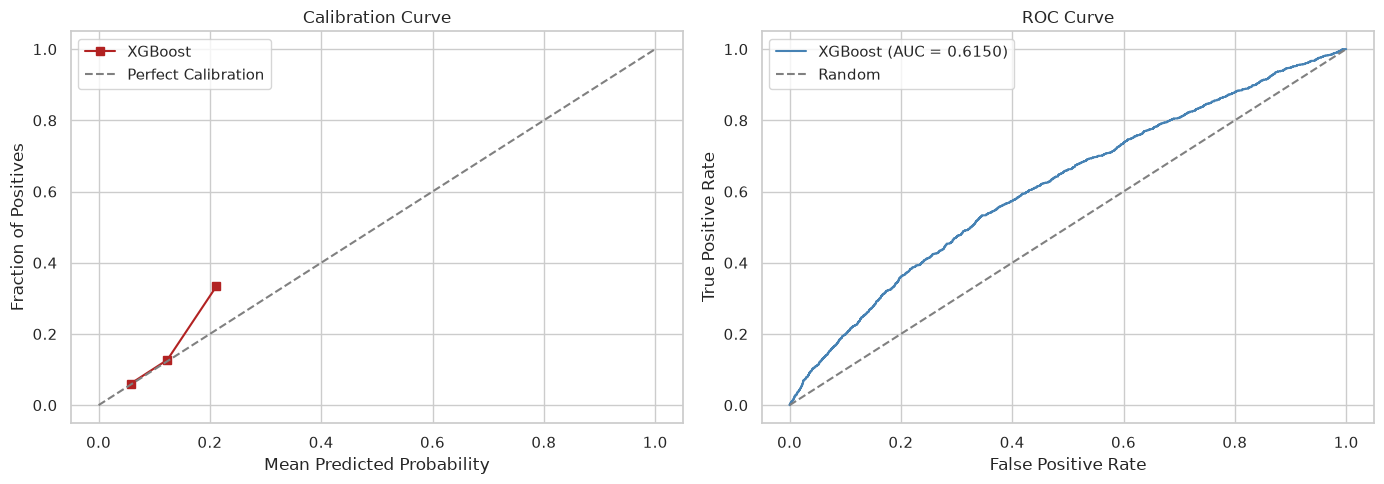

In [16]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_pred_proba2, n_bins=10
)

axes[0].plot(mean_predicted_value, fraction_of_positives, 
             's-', color='firebrick', label='XGBoost')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve')
axes[0].legend()

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba2)
axes[1].plot(fpr, tpr, color='steelblue', label=f'XGBoost (AUC = {auc2:.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../nfl/figures/calibration_roc.png', dpi=150, bbox_inches='tight')
plt.show()

**Calibration & ROC Notes:**
- **Calibration:** The model's predictions are concentrated in the 0.05–0.22 range, reflecting the low base rate of sacks. The curve runs slightly above the diagonal, indicating a modest tendency to overestimate sack probability. Isotonic regression or Platt scaling could improve this further.
- **ROC Curve:** The curve bows meaningfully above the diagonal across all thresholds, confirming the model has genuine discriminative ability beyond random chance. The steeper lift at low FPR values is particularly valuable for a use case where you want high-confidence sack predictions.

### 4.5 Feature Importance

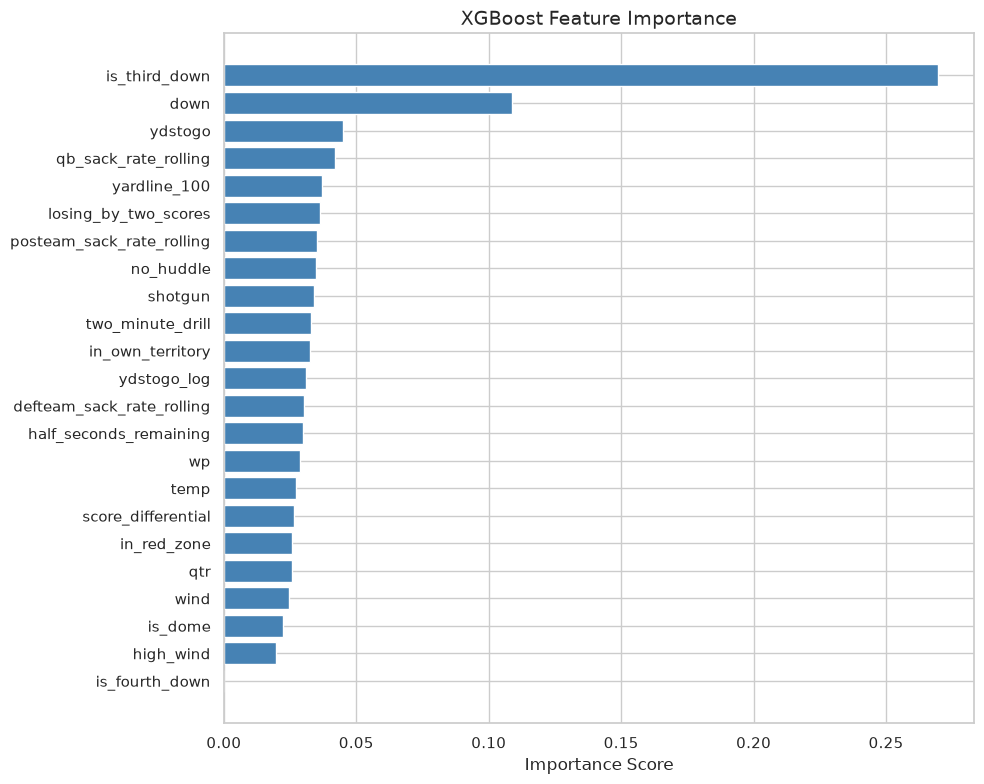

In [17]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance': xgb_model2.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('XGBoost Feature Importance', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../nfl/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature Importance Notes:**
- **`is_third_down`** is the dominant feature by a wide margin (0.27), confirming what we saw in EDA — 3rd down is by far the highest sack situation as defenses can sell out on the pass rush
- **`down`** (raw) is second at 0.11, capturing the ordinal relationship across all downs
- **`ydstogo` and `qb_sack_rate_rolling`** are next — distance to go drives pass rush aggression, and QB-level sack tendency is a meaningful individual signal
- **`yardline_100`, `losing_by_two_scores`, `posteam_sack_rate_rolling`** all contribute similarly, reflecting field position, game script, and offensive line quality
- **`no_huddle` and `shotgun`** both appear, consistent with formation affecting pass rush timing
- **Weather features** (`wind`, `temp`, `is_dome`) contribute modestly but are present
- **`is_fourth_down`** has near-zero importance — likely because 4th down dropbacks are rare and context-specific enough that the model can't generalize well from them

## 5. Discussion & Limitations

### What Worked
- Time-based train/test split preserved temporal integrity and prevented data leakage
- Rolling team and QB sack rates added meaningful signal beyond raw situational features
- Dropping `scale_pos_weight` dramatically improved probability calibration
- ROC-AUC of 0.615 is respectable for a task with this much inherent randomness

### Limitations & Future Work
- **No player-level pass rush data:** The biggest missing signal is individual pass rusher quality (e.g. Micah Parsons vs. a replacement-level DE). Snap count and depth chart data could be used to build a weighted pass rush rating per game
- **No pre-snap motion or personnel grouping:** 11 vs 12 personnel affects blocking assignments significantly
- **Sacks are noisy:** A sack is often the result of a single broken assignment or a QB holding the ball too long — both hard to predict from aggregate features
- **Calibration:** Isotonic regression or Platt scaling post-processing could tighten the calibration curve
- **Hyperparameter tuning:** Early stopping triggered at tree 72 — a proper grid search or Optuna sweep could squeeze more performance out